In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')
path = '/content/train_u6lujuX_CVtuZ9i.csv'
df = pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
print(df['Loan_Status'].value_counts())


Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [ ]:
df=df.drop(['Loan_ID','Gender',],axis=1)

In [ ]:
df.head()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Married']=le.fit_transform(df['Married'])
df['Education']=le.fit_transform(df['Education'])
df['Self_Employed']=le.fit_transform(df['Self_Employed'])
df['Property_Area']=le.fit_transform(df['Property_Area'])
df['Loan_Status']=le.fit_transform(df['Loan_Status'])
df.isnull().sum()
df['Dependents']=df['Dependents'].replace(to_replace='3+',value=3)
df['Dependents']=df['Dependents'].astype(float)
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mean())
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mean())
df.isnull().sum()


,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Property_Area,0


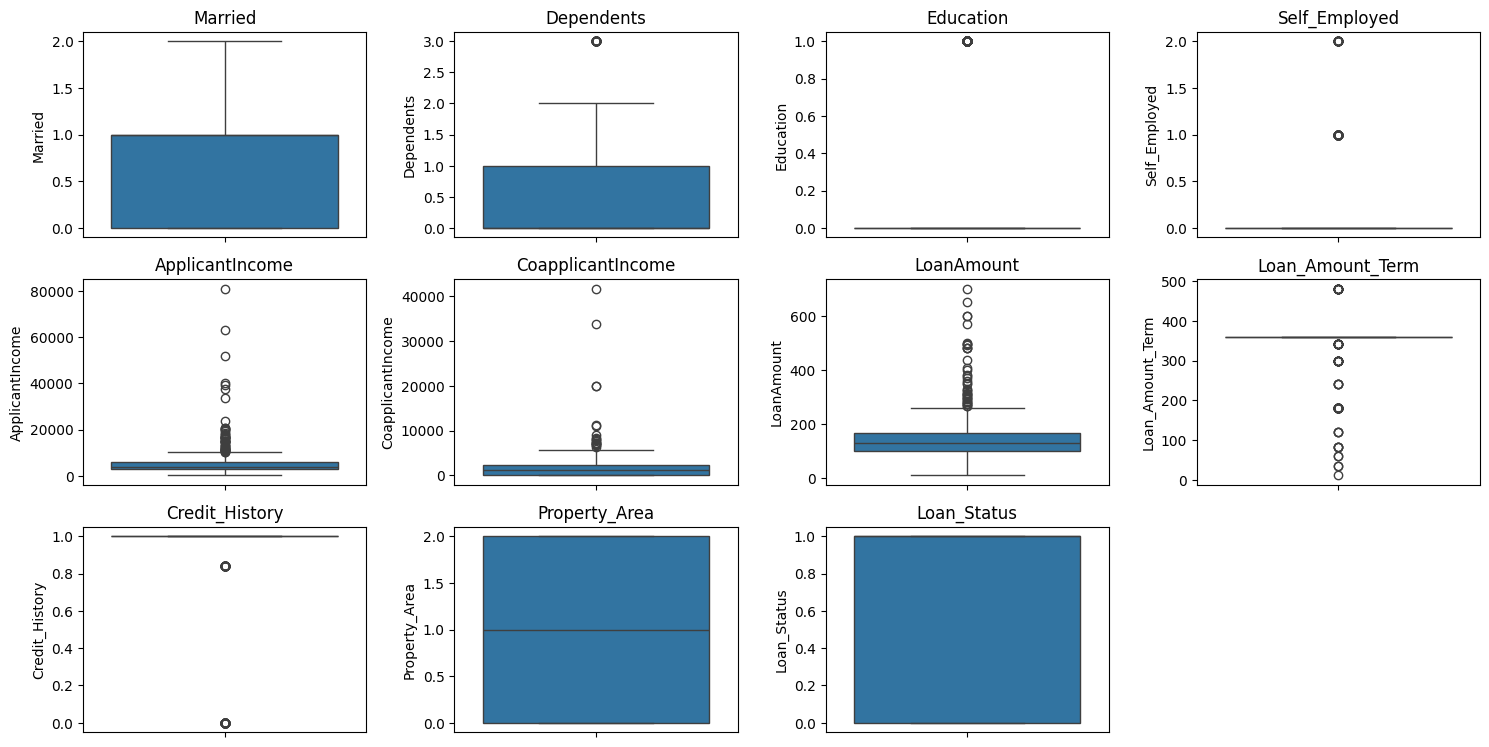

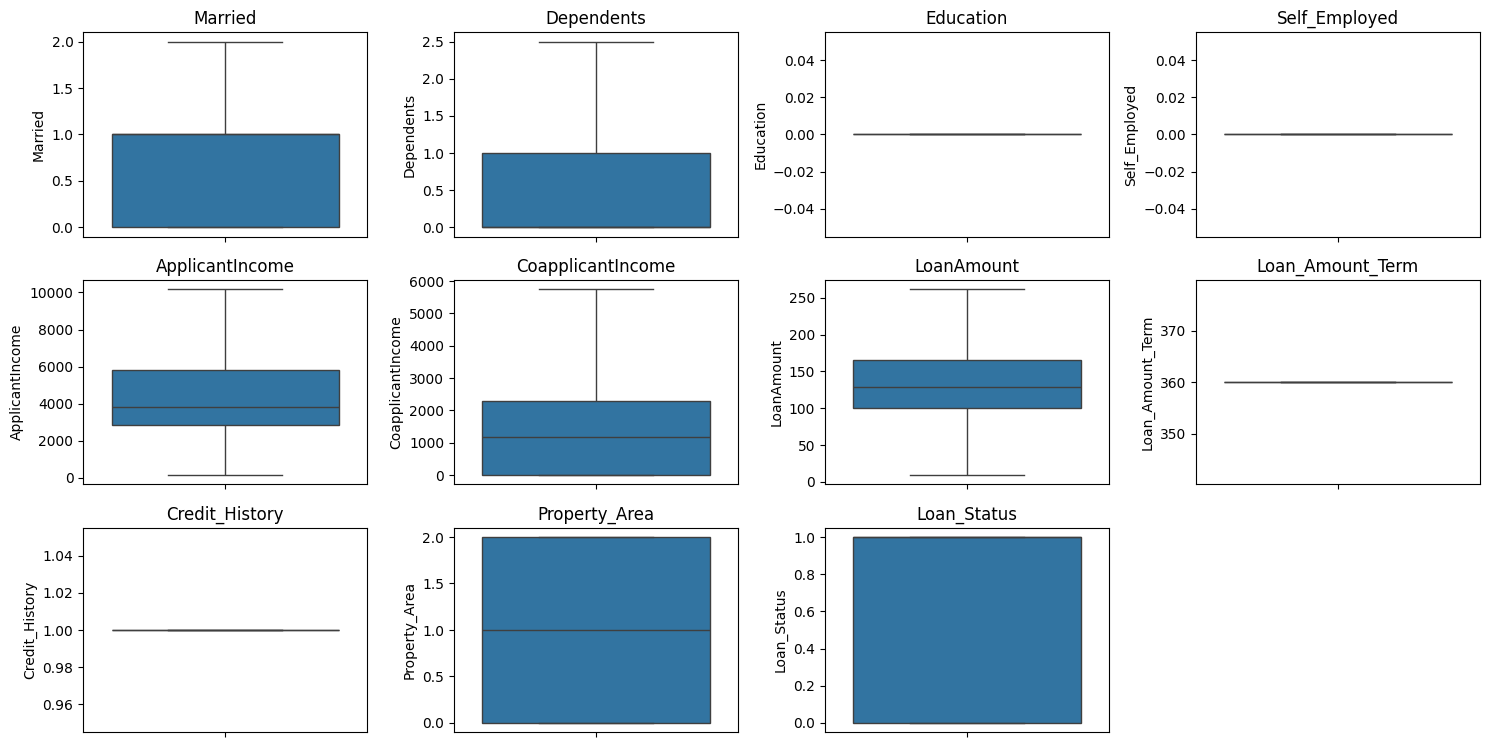

Final dataset shape after handling outliers: (614, 11)
     Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0        0.0         0.0        0.0            0.0           5849.0   
1        1.0         1.0        0.0            0.0           4583.0   
2        1.0         0.0        0.0            0.0           3000.0   
3        1.0         0.0        0.0            0.0           2583.0   
4        0.0         0.0        0.0            0.0           6000.0   
..       ...         ...        ...            ...              ...   
609      0.0         0.0        0.0            0.0           2900.0   
610      1.0         2.5        0.0            0.0           4106.0   
611      1.0         1.0        0.0            0.0           8072.0   
612      1.0         2.0        0.0            0.0           7583.0   
613      0.0         0.0        0.0            0.0           4583.0   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Exclude 'Loan_Status' from outlier removal
num_cols_for_outlier_removal = [col for col in num_cols if col != 'Loan_Status']

for col in num_cols_for_outlier_removal:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers instead of removing rows
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])


plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


print("Final dataset shape after handling outliers:", df.shape)
print(df)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC # Changed SVM to SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [ ]:

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
dt = DecisionTreeClassifier(class_weight='balanced')
rf = RandomForestClassifier(class_weight='balanced')
svm = SVC(probability=True, class_weight='balanced')
knn = KNeighborsClassifier()

svm=SVC()

base_models=[lr,dt,rf,knn,svm]
meta_model = LogisticRegression(class_weight='balanced', max_iter=1000)

x=df.drop(['Loan_Status'],axis=1).values
y=df['Loan_Status']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
print("Overall class distribution:")
print(y.value_counts())

print("\nTrain class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())


Overall class distribution:
Loan_Status
1    422
0    192
Name: count, dtype: int64

Train class distribution:
Loan_Status
1    342
0    149
Name: count, dtype: int64

Test class distribution:
Loan_Status
1    80
0    43
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import StackingClassifier # Changed StackingRegressor to StackingClassifier
#from sklearn.linear_model import LinearRegression # Import LinearRegression for a regression task

lr = LogisticRegression() # Initialize LogisticRegression for a classification task
base_models = [('lr', lr), ('dt', dt), ('rf', rf), ('knn', knn), ('svm', svm)] # Wrap models in (name, estimator) tuples

classifier = StackingClassifier(estimators=base_models, final_estimator=meta_model) # Changed StackingRegressor to StackingClassifier
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[[20 23]
 [32 48]]
              precision    recall  f1-score   support

           0       0.38      0.47      0.42        43
           1       0.68      0.60      0.64        80

    accuracy                           0.55       123
   macro avg       0.53      0.53      0.53       123
weighted avg       0.57      0.55      0.56       123

0.5528455284552846


<Axes: >

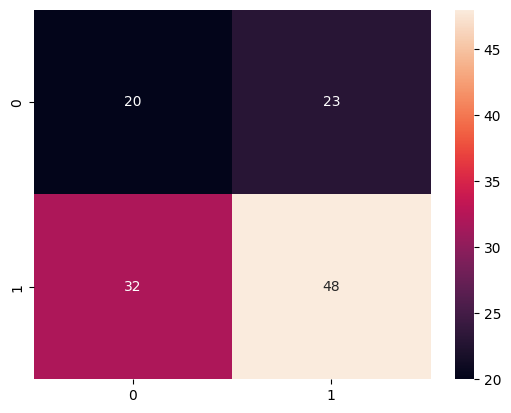

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
sns.heatmap(cm,annot=True,fmt='d')


In [ ]:
print(y_train.value_counts(normalize=True))


Loan_Status
1    0.696538
0    0.303462
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')
path = '/content/Mall_Customers.csv'
df = pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Genre']=le.fit_transform(df['Genre'])
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [ ]:
X=df.iloc[:,3:].values

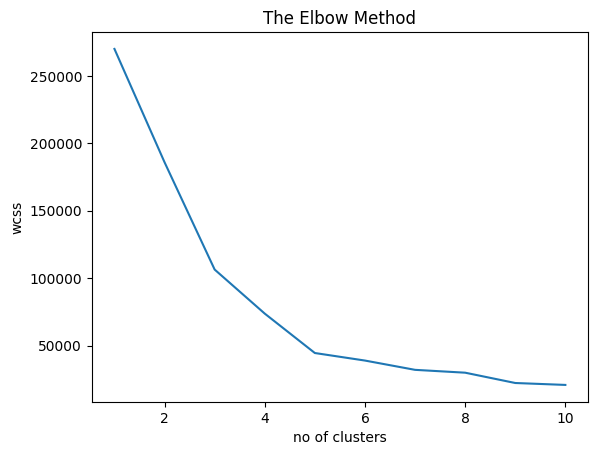

In [ ]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=0)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('no of clusters')
plt.ylabel('wcss')
plt.show()

In [ ]:
y_kmeans=kmeans.fit_predict(X)
y_kmeans


array([3, 4, 7, 4, 3, 4, 7, 4, 7, 4, 7, 4, 7, 4, 7, 4, 3, 4, 3, 4, 3, 4,
       7, 4, 7, 4, 3, 4, 3, 4, 7, 4, 7, 4, 7, 4, 7, 4, 3, 4, 3, 4, 3, 6,
       3, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 0, 6, 6, 0, 6, 0, 6, 6, 0, 0, 6, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 9, 2, 1, 2, 9, 2, 9, 2, 1, 0, 1, 2, 1, 0, 9, 2, 1, 2, 1, 2, 9,
       2, 1, 2, 9, 2, 9, 2, 1, 2, 1, 2, 9, 2, 1, 2, 9, 2, 9, 2, 1, 2, 9,
       2, 9, 2, 9, 8, 9, 8, 9, 8, 1, 8, 9, 8, 9, 8, 9, 8, 5, 8, 5, 8, 5,
       8, 5], dtype=int32)

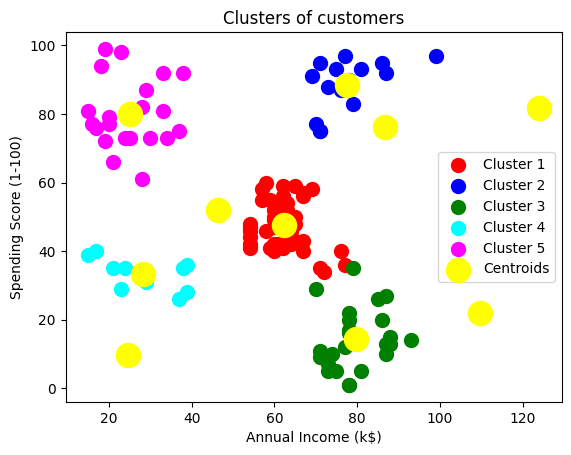

In [ ]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1],
            s=100, c='red', label='Cluster 1')

plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1],
            s=100, c='blue', label='Cluster 2')

plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1],
            s=100, c='green', label='Cluster 3')

plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1],
            s=100, c='cyan', label='Cluster 4')

plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1],
            s=100, c='magenta', label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroids')

plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')
path = '/content/Wholesale customers data.csv'
df = pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [ ]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
X=df.iloc[:,:].values

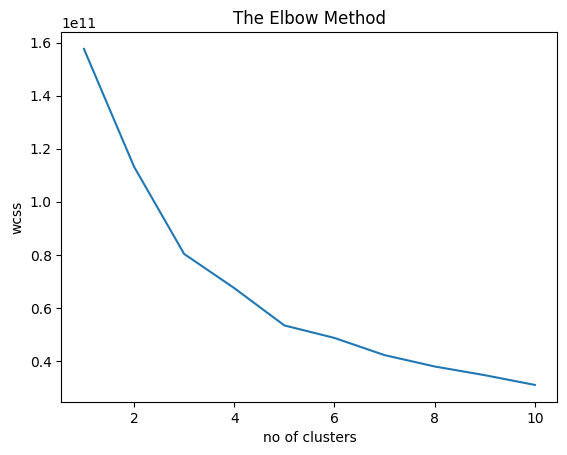

In [ ]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=0)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('no of clusters')
plt.ylabel('wcss')
plt.show()

In [ ]:
y_kmeans=kmeans.fit_predict(X)
y_kmeans


array([9, 7, 7, 9, 0, 1, 9, 7, 1, 7, 7, 9, 0, 0, 0, 9, 7, 1, 0, 1, 9, 1,
       0, 6, 0, 9, 9, 9, 2, 4, 9, 1, 9, 0, 1, 7, 0, 7, 7, 4, 0, 9, 7, 2,
       7, 2, 2, 6, 7, 2, 1, 1, 4, 7, 0, 1, 2, 7, 9, 1, 1, 6, 1, 7, 1, 2,
       1, 0, 1, 1, 9, 0, 1, 0, 7, 9, 1, 2, 9, 1, 1, 7, 7, 9, 9, 5, 6, 4,
       1, 0, 9, 9, 2, 8, 7, 1, 1, 1, 1, 9, 7, 7, 7, 4, 9, 9, 7, 7, 7, 2,
       9, 7, 9, 9, 9, 9, 9, 1, 9, 1, 9, 1, 9, 7, 0, 4, 9, 0, 1, 4, 1, 1,
       9, 1, 1, 1, 7, 7, 9, 1, 9, 0, 0, 9, 9, 2, 1, 1, 1, 0, 9, 1, 9, 1,
       1, 7, 7, 9, 7, 7, 7, 9, 9, 2, 7, 7, 7, 1, 1, 1, 7, 2, 1, 7, 1, 7,
       4, 9, 9, 1, 9, 3, 7, 6, 1, 1, 1, 7, 7, 7, 9, 9, 1, 7, 1, 9, 0, 7,
       9, 1, 2, 2, 0, 1, 1, 2, 1, 1, 1, 7, 9, 2, 1, 1, 7, 7, 2, 9, 7, 1,
       9, 7, 1, 1, 1, 9, 0, 1, 1, 1, 9, 1, 0, 1, 9, 1, 1, 9, 1, 4, 0, 0,
       9, 9, 7, 7, 1, 9, 9, 1, 1, 2, 1, 0, 7, 0, 9, 1, 4, 4, 1, 1, 0, 1,
       7, 7, 7, 9, 7, 9, 1, 1, 1, 4, 1, 1, 0, 9, 9, 9, 1, 9, 4, 0, 4, 4,
       1, 9, 9, 4, 1, 1, 1, 7, 0, 1, 9, 1, 7, 1, 9,

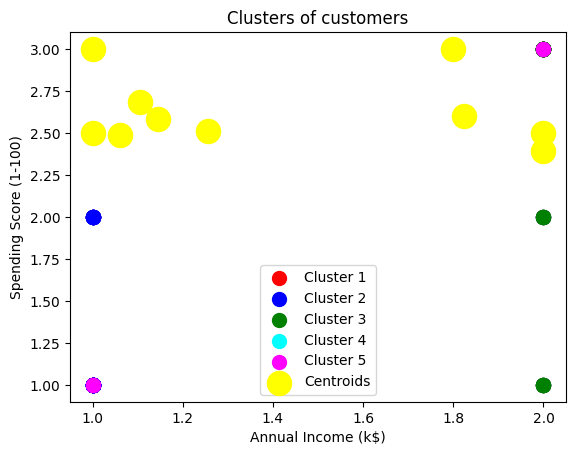

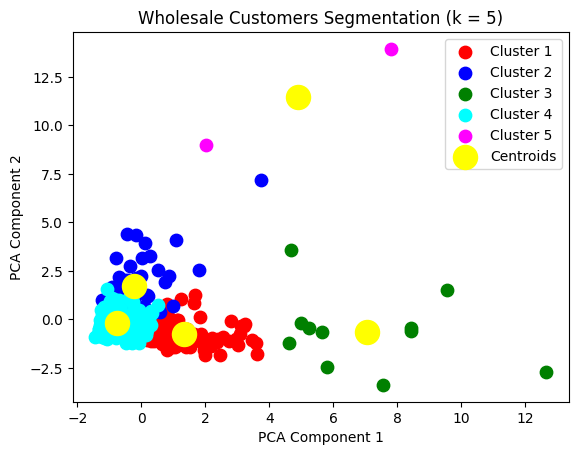

In [ ]:
X = df.iloc[:, 2:].values
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(kmeans.cluster_centers_)
import matplotlib.pyplot as plt

colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(5):
    plt.scatter(
        X_pca[y_kmeans == i, 0],
        X_pca[y_kmeans == i, 1],
        s=80,
        c=colors[i],
        label=f'Cluster {i+1}'
    )

# Centroids
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=300,
    c='yellow',
    label='Centroids'
)

plt.title('Wholesale Customers Segmentation (k = 5)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()
